<a href="https://colab.research.google.com/github/Riya0876-G/Countries-GDP/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from typing import Tuple, Dict, List

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
print('Imports complete')

Imports complete


In [2]:
def load_csv(path: str, nrows: int = None) -> pd.DataFrame:
    """Load a CSV and show a brief summary.

    Args:
        path: path to csv file
        nrows: optional number of rows to read for quick inspection
    Returns:
        DataFrame
    """
    df = pd.read_csv(path, nrows=nrows)
    print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns from: {path}")
    display(df.head())
    print('\nColumn dtypes:')
    print(df.dtypes)
    return df

In [3]:
def build_preprocessor(df: pd.DataFrame, ignore_cols: List[str] = None) -> ColumnTransformer:
    if ignore_cols is None:
        ignore_cols = []

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    numeric_cols = [c for c in numeric_cols if c not in ignore_cols]
    cat_cols = [c for c in cat_cols if c not in ignore_cols]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, cat_cols),
    ], remainder='drop')

    print(f'Numeric columns detected: {numeric_cols}')
    print(f'Categorical columns detected: {cat_cols}')
    return preprocessor

In [4]:
def eda_summary(df: pd.DataFrame, target: str = None, max_cat_values: int = 10):
    print('Shape:', df.shape)
    print('\nMissing values per column:')
    print(df.isna().sum().sort_values(ascending=False).head(30))
    print('\nNumerical summary:')
    display(df.describe().T)

    print('\nCategorical summary (top value counts):')
    for c in df.select_dtypes(include=['object', 'category']).columns:
        print(f'\nColumn: {c}')
        print(df[c].value_counts(dropna=False).head(max_cat_values))

    if target is not None and target in df.columns:
        print(f"\nTarget '{target}' distribution:")
        print(df[target].value_counts(dropna=False).head(20))

def plot_correlation_matrix(df: pd.DataFrame, figsize: Tuple[int,int]=(8,6)):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] < 2:
        print('Not enough numeric columns for correlation matrix.')
        return
    corr = num.corr()
    plt.figure(figsize=figsize)
    plt.imshow(corr, cmap='coolwarm', interpolation='none')
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title('Correlation matrix')
    plt.tight_layout()
    plt.show()

In [5]:
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNeighbors': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=0),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=0),
    'SVC': SVC(probability=True),
}

REGRESSORS = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=0),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=0),
}

print('Model dictionaries defined')

Model dictionaries defined


In [6]:
def is_classification_task(y: pd.Series) -> bool:
    if not pd.api.types.is_numeric_dtype(y):
        return True
    nunique = y.nunique()
    if nunique <= 20 and nunique < 0.1 * len(y):
        return True
    return False

print('Heuristic ready')

Heuristic ready


In [7]:
def train_and_evaluate(df: pd.DataFrame, target: str, test_size: float = 0.2, random_state: int = 0) -> Dict:
    X = df.drop(columns=[target])
    y = df[target]

    task_is_clf = is_classification_task(y)
    print(f"Detected task: {'classification' if task_is_clf else 'regression'}")

    preprocessor = build_preprocessor(df, ignore_cols=[target])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    results = {}
    models = CLASSIFIERS if task_is_clf else REGRESSORS

    for name, model in models.items():
        print(f"Training: {name}")
        pipe = Pipeline([('preprocessor', preprocessor), ('estimator', model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        if task_is_clf:
            try:
                y_proba = pipe.predict_proba(X_test)[:, 1]
            except Exception:
                y_proba = None
            metrics = {
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
                'recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
                'f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
            }
            if y_proba is not None and len(np.unique(y_test)) == 2:
                try:
                    metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
                except Exception:
                    metrics['roc_auc'] = np.nan
            results[name] = {'metrics': metrics, 'y_test': y_test, 'y_pred': y_pred, 'y_proba': y_proba}
        else:
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
            results[name] = {'metrics': metrics, 'y_test': y_test, 'y_pred': y_pred}

        print('Metrics:', results[name]['metrics'])

    return {'task': 'classification' if task_is_clf else 'regression', 'results': results}

In [8]:
def plot_metrics(results_dict: Dict, figsize: Tuple[int,int]=(10,6)):
    task = results_dict['task']
    results = results_dict['results']

    rows = []
    for model_name, info in results.items():
        m = info['metrics'].copy()
        m['model'] = model_name
        rows.append(m)
    dfm = pd.DataFrame(rows).set_index('model')

    for col in dfm.columns:
        plt.figure(figsize=figsize)
        ascending = col in ['mse','rmse','mae']
        dfm[col].sort_values(ascending=ascending).plot(kind='bar')
        plt.title(f'{col} by model')
        plt.ylabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    if task == 'classification':
        from sklearn.metrics import roc_curve, auc
        has_plotted = False
        for name, info in results.items():
            y_test = info.get('y_test')
            y_proba = info.get('y_proba')
            if y_proba is not None and y_test is not None and len(np.unique(y_test)) == 2:
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
                has_plotted = True
        if has_plotted:
            plt.plot([0,1],[0,1],'k--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC curves')
            plt.legend()
            plt.show()

Loaded 400 rows and 21 columns from: /content/final output for analysis.csv


,Uae,Usa,Chad,SierraLleone,Netherlands,Marshallislands,Japan,Ind,Germany,Zimbabwe,...,Saudiarabia,Burundi,Korea,Comoros,Haiti,Kiribati,Nauru,Singapore,Vanuatu,Target
0,4.855141,3.483550,7.366322,2.033963,4.358237,1.803901,7.923431,0.885485,11.458238,5.944896,...,17.332534,5.665202,3.072173,1.292430,2.400000,-5.711125,5.305326,1.791045,0.0,4.353500
1,9.837320,2.784540,9.006766,3.537375,5.245006,1.372350,8.060733,3.866682,12.674675,3.313485,...,-0.542830,-1.754447,1.768751,5.776934,8.450704,-3.461403,8.460697,0.175953,0.0,4.283111
2,3.184390,2.003858,9.021520,3.885306,5.841963,1.483969,7.660815,2.889117,14.149985,2.213654,...,4.200174,0.803600,4.706530,3.055080,-22.077922,-3.653251,2.875892,3.688525,0.0,3.749758
3,3.191836,0.113587,1.863483,2.116816,3.004405,-1.224289,3.086698,0.887902,9.670246,6.237988,...,3.081190,3.964611,2.658032,-2.984731,20.000000,-17.668999,5.600992,-7.566347,0.0,3.686060
4,-5.242922,-2.576500,0.127953,-3.665290,0.819862,-5.693236,7.861889,-5.544555,9.402700,-1.066717,...,-1.408283,3.240602,5.890379,0.536801,-5.555556,13.272055,3.037304,3.665241,0.0,1.530803



Column dtypes:
Uae                float64
Usa                float64
Chad               float64
SierraLleone       float64
Netherlands        float64
Marshallislands    float64
Japan              float64
Ind                float64
Germany            float64
Zimbabwe           float64
China              float64
Saudiarabia        float64
Burundi            float64
Korea              float64
Comoros            float64
Haiti              float64
Kiribati           float64
Nauru              float64
Singapore          float64
Vanuatu            float64
Target             float64
dtype: object
Shape: (400, 21)

Missing values per column:
Uae                0
Usa                0
Chad               0
SierraLleone       0
Netherlands        0
Marshallislands    0
Japan              0
Ind                0
Germany            0
Zimbabwe           0
China              0
Saudiarabia        0
Burundi            0
Korea              0
Comoros            0
Haiti              0
Kiribati           0
N

,count,mean,std,min,25%,50%,75%,max
Uae,400.0,3.066566,4.142016,-8.693426,1.537167,4.301182,4.918478,9.837320
Usa,400.0,1.988222,1.831423,-2.576500,1.819451,2.512375,2.793001,6.055053
Chad,400.0,4.442685,3.893381,-3.814709,1.863483,4.108000,6.214934,14.519750
SierraLleone,400.0,1.491007,2.398051,-3.867953,0.000000,2.033963,2.424286,6.276831
Netherlands,400.0,3.051151,1.771326,-0.700242,2.313802,3.171527,3.688032,6.981661
Marshallislands,400.0,0.513980,2.099793,-5.693236,0.023810,0.941999,1.560627,4.097918
Japan,400.0,6.087846,3.446369,-5.777725,5.456388,7.410228,7.996254,9.689592
Ind,400.0,1.089476,2.404180,-5.544555,0.396996,1.135696,2.797907,4.134638
Germany,400.0,7.524842,3.303275,0.000000,6.068502,7.461900,9.461336,14.149985
Zimbabwe,400.0,3.602772,3.678345,-3.804789,1.651589,3.226951,5.761574,12.000587



Categorical summary (top value counts):

Target 'Target' distribution:
Target
-5.555556    2
 6.453851    1
 6.795383    1
 8.256306    1
 7.996254    1
 7.410228    1
 6.386106    1
 5.456388    1
 5.241316    1
 8.497585    1
 7.861889    1
 3.871437    1
 7.660815    1
 8.060733    1
 7.923431    1
-0.495852    1
-0.869648    1
 1.809258    1
 3.910000    1
-4.131914    1
Name: count, dtype: int64


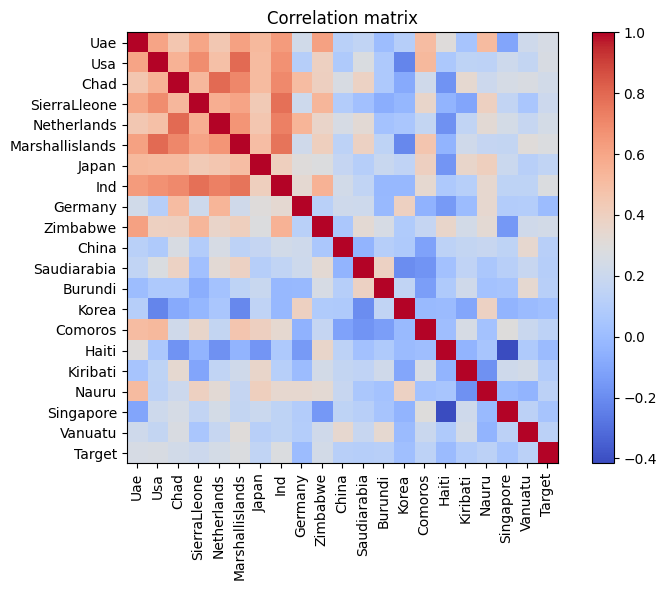

Detected task: regression
Numeric columns detected: ['Uae', 'Usa', 'Chad', 'SierraLleone', 'Netherlands', 'Marshallislands', 'Japan', 'Ind', 'Germany', 'Zimbabwe', 'China', 'Saudiarabia', 'Burundi', 'Korea', 'Comoros', 'Haiti', 'Kiribati', 'Nauru', 'Singapore', 'Vanuatu']
Categorical columns detected: []
Training: LinearRegression
Metrics: {'mse': 15.442566063170569, 'rmse': np.float64(3.929703050253361), 'mae': 2.7932898288058636, 'r2': 0.0057639177513001405}
Training: Ridge
Metrics: {'mse': 15.424393782823927, 'rmse': np.float64(3.9273901999704495), 'mae': 2.7908765158022133, 'r2': 0.006933900560080919}
Training: KNeighborsRegressor
Metrics: {'mse': 22.15767282600462, 'rmse': np.float64(4.707193731513992), 'mae': 3.5084667950450004, 'r2': -0.4265736492340615}
Training: DecisionTreeRegressor
Metrics: {'mse': 25.703707814548903, 'rmse': np.float64(5.069882426107029), 'mae': 3.5474831229499997, 'r2': -0.6548774117114244}
Training: RandomForestRegressor
Metrics: {'mse': 14.21640132921370

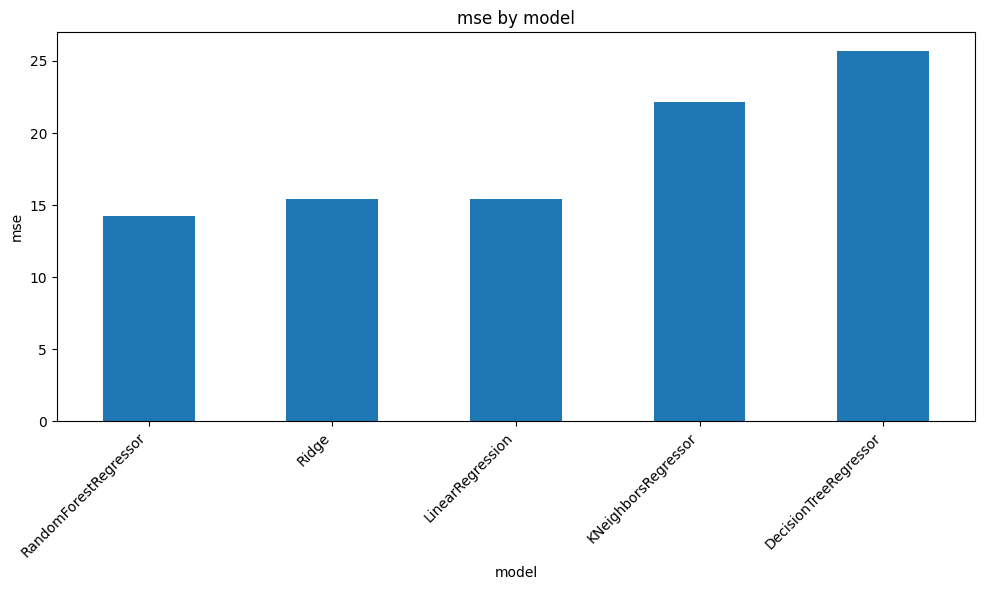

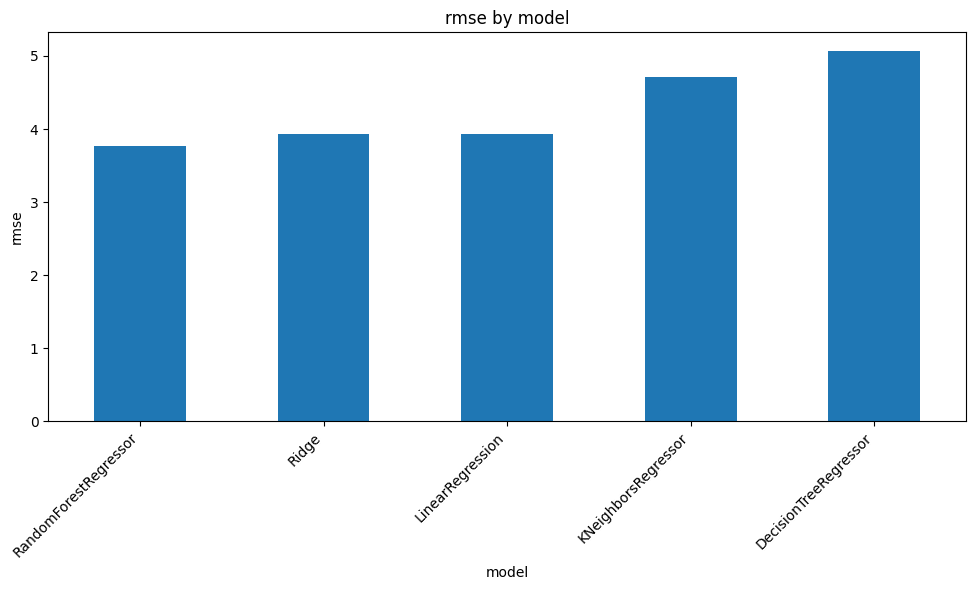

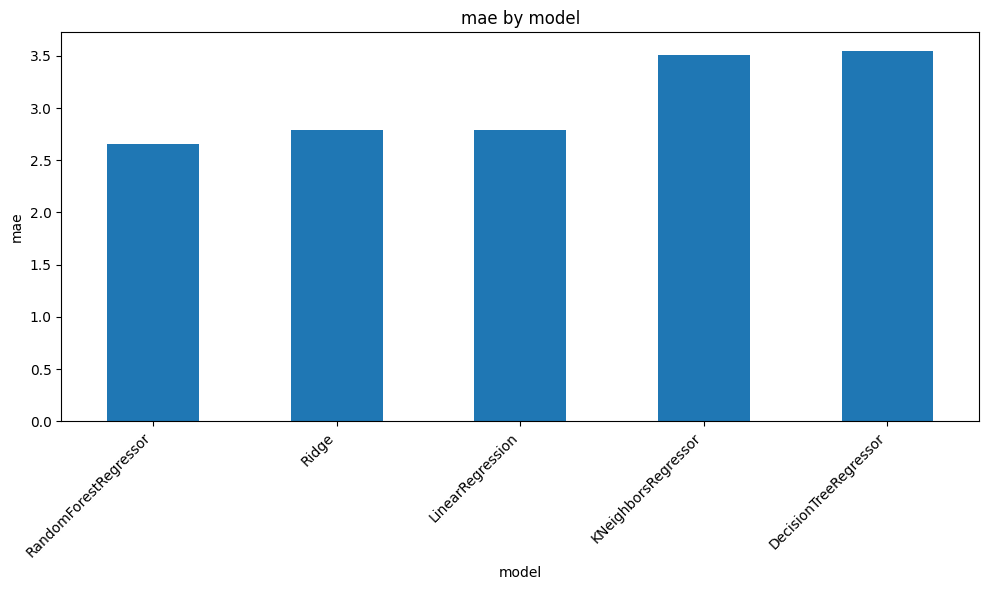

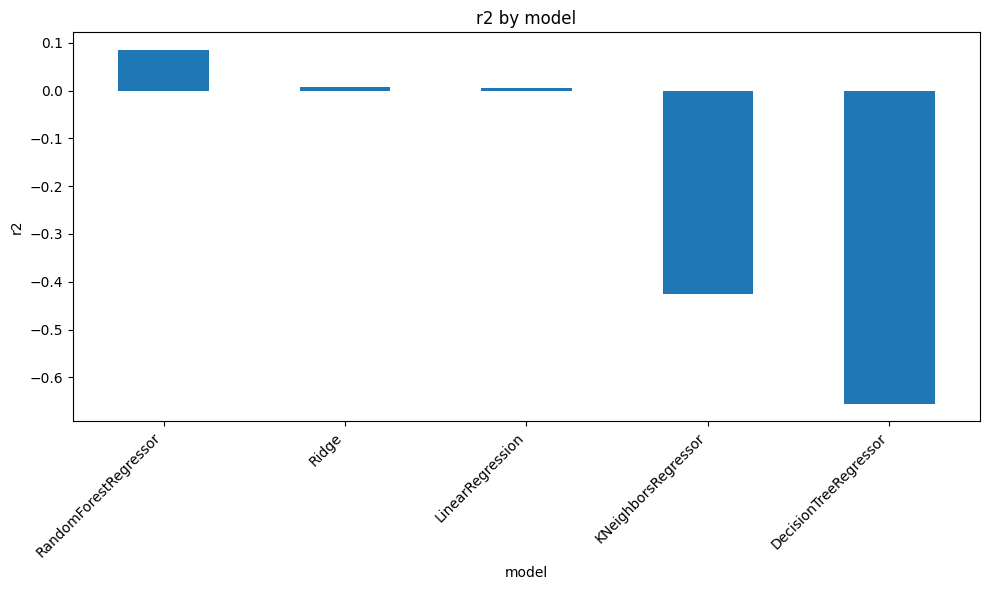

Edit the example cell and run to execute the pipeline


In [9]:
df = load_csv('/content/final output for analysis.csv')
eda_summary(df, target='Target')
plot_correlation_matrix(df)
results = train_and_evaluate(df, target='Target')
plot_metrics(results)

print('Edit the example cell and run to execute the pipeline')

# New Section